# Unsupervised Learning with K-Means Clustering

### Part 1

In [1]:
import pandas as pd

# import dataset
data_frame = pd.read_csv("data/heart.csv")

In [2]:
# first rows of dataset
print(data_frame.head(5))

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  


In [3]:
# dataset shape (number of columns/rows)
print("number of columns:", data_frame.shape[1])
print("number of rows:", data_frame.shape[0])

number of columns: 14
number of rows: 1025


In [4]:
# column names and data types
print(data_frame.dtypes)

age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object


In [5]:
# remove target column
data_frame = data_frame.drop('target', axis=1)
print(data_frame.dtypes)

age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
dtype: object


In [6]:
# compute statistics(mean / standard deviation / minimum / maximum)
# 1. mean
print("mean:\n", data_frame.mean())

mean:
 age          54.434146
sex           0.695610
cp            0.942439
trestbps    131.611707
chol        246.000000
fbs           0.149268
restecg       0.529756
thalach     149.114146
exang         0.336585
oldpeak       1.071512
slope         1.385366
ca            0.754146
thal          2.323902
dtype: float64


In [7]:
# 2. standard deviation
print("standard deviation:\n", data_frame.std())

standard deviation:
 age          9.072290
sex          0.460373
cp           1.029641
trestbps    17.516718
chol        51.592510
fbs          0.356527
restecg      0.527878
thalach     23.005724
exang        0.472772
oldpeak      1.175053
slope        0.617755
ca           1.030798
thal         0.620660
dtype: float64


In [8]:
# 3. minimum
print("minimum:\n", data_frame.min())

minimum:
 age          29.0
sex           0.0
cp            0.0
trestbps     94.0
chol        126.0
fbs           0.0
restecg       0.0
thalach      71.0
exang         0.0
oldpeak       0.0
slope         0.0
ca            0.0
thal          0.0
dtype: float64


In [9]:
# 3. minimum
print("maximum:\n", data_frame.max())

maximum:
 age          77.0
sex           1.0
cp            3.0
trestbps    200.0
chol        564.0
fbs           1.0
restecg       2.0
thalach     202.0
exang         1.0
oldpeak       6.2
slope         2.0
ca            4.0
thal          3.0
dtype: float64


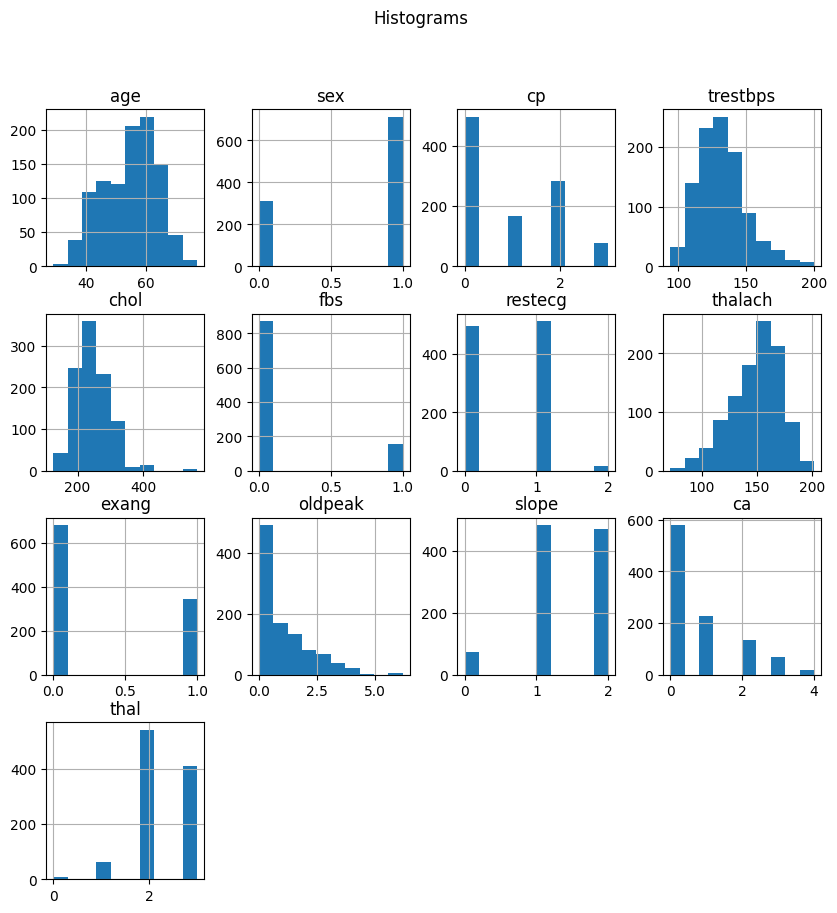

In [10]:
# analyze dataset distributions (histograms / box plots/ scatter plots)
import matplotlib.pyplot as plt

# 1. histograms
data_frame.hist(figsize=(10, 10))
plt.suptitle("Histograms")
plt.show()

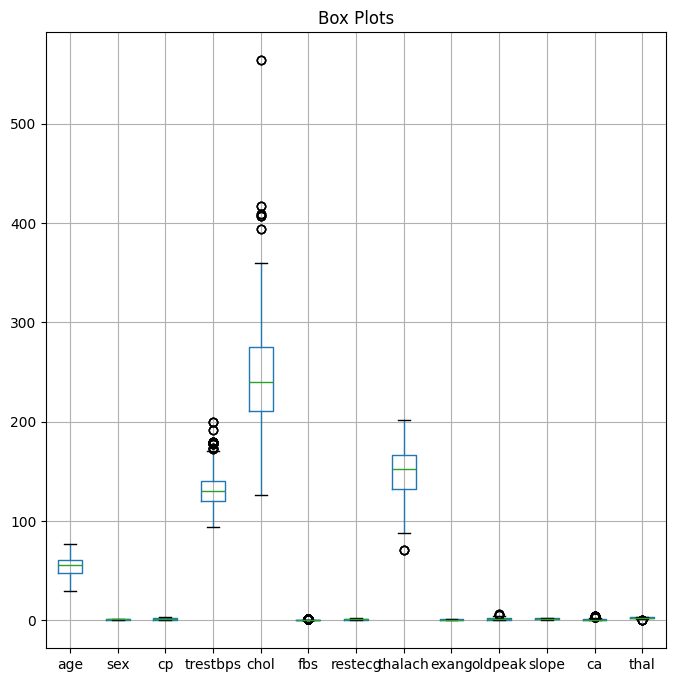

In [11]:
# 2. box plots 
data_frame.boxplot(figsize=(8, 8))
plt.title("Box Plots")
plt.show()

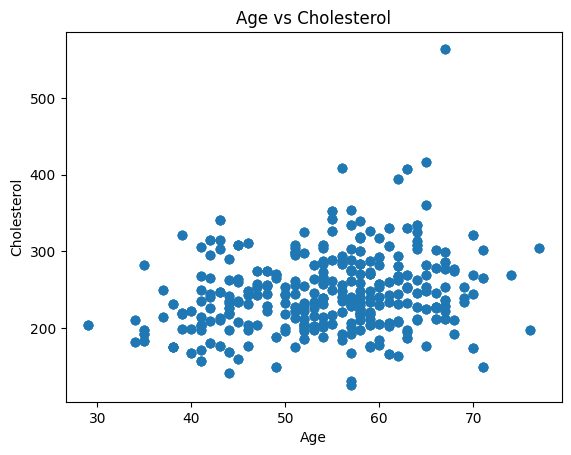

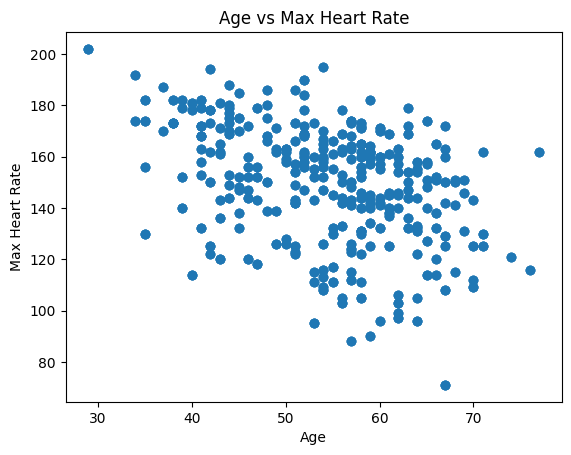

In [12]:
# 3. scatter plots (for selected features)
# age and cholesterol
plt.scatter(data_frame['age'], data_frame['chol'])
plt.xlabel('Age')
plt.ylabel('Cholesterol')
plt.title('Age vs Cholesterol')
plt.show()

# age and max heart rate
plt.scatter(data_frame['age'], data_frame['thalach'])
plt.xlabel('Age')
plt.ylabel('Max Heart Rate')
plt.title('Age vs Max Heart Rate')
plt.show()

In [13]:
# identify missing values
print("missing values:\n", data_frame.isnull().sum())

# remove missing values
data_frame = data_frame.dropna()

missing values:
 age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
dtype: int64


In [14]:
# irrelevant columns
# According to the data frame columns, there are no irrelevant columns; all columns are suitable for unsupervised learning.

In [15]:
# check for duplicates
print("Number of duplicate rows:", data_frame.duplicated().sum())

print("number of rows before: ", data_frame.shape[0])

# remove duplicate rows
data_frame = data_frame.drop_duplicates()
print("Doublons supprimés")

print("number of rows after: ", data_frame.shape[0])

Number of duplicate rows: 723
number of rows before:  1025
Doublons supprimés
number of rows after:  302


In [16]:
# encode categorical variables ( using the one hot encoding )
# (column with values A, B, C becomes three columns: A, B, C with 0/1 values)
data_frame = pd.get_dummies(data_frame, drop_first=True)
print("encoded categorical variables")
print("current columns:", data_frame.columns)

encoded categorical variables
current columns: Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal'],
      dtype='object')


In [17]:
# select the features to be used for clustering (numerical values)
features = data_frame
print("features for clustering:", features.shape[1])

features for clustering: 13


In [18]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# standardize numerical features
standard_scaler = StandardScaler()
features_scaled = standard_scaler.fit_transform(features)
print("features standardized, shape:", features_scaled.shape)

# normalize numerical features
normalize_scaler = MinMaxScaler()
features_normalized = normalize_scaler.fit_transform(features)
print("features normalized, shape:", features_normalized.shape)

features standardized, shape: (302, 13)
features normalized, shape: (302, 13)


### Part 2

In [19]:
from sklearn.model_selection import train_test_split

# split the dataset into a training set (80%) and a test set(20%)
x_train, x_test = train_test_split(features_scaled, test_size=0.2)
print("train shape", x_train.shape)
print("test shape", x_test.shape)

# splitting is useful in unsupervised learning to test cluster generalization and stability

train shape (241, 13)
test shape (61, 13)


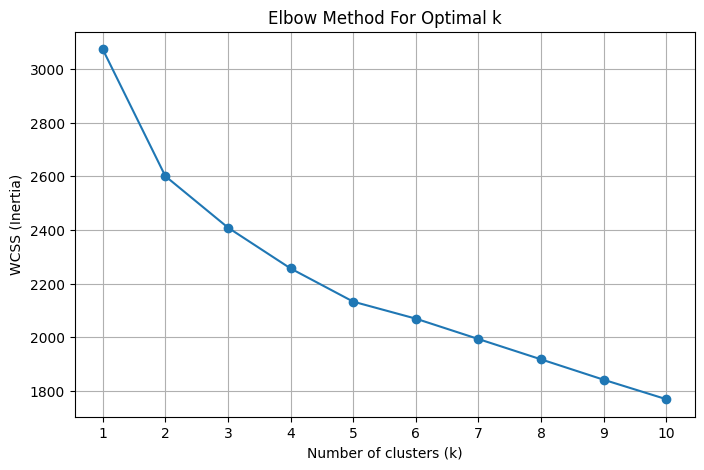

In [20]:
# apply Elbow Method to determine the optimal number of clusters k
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np

wcss = []  # Within-cluster sum of squares
k_range = range(1, 11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(x_train)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, wcss, marker='o')
plt.title('Elbow Method For Optimal k')
plt.xlabel('Number of clusters (k)')
plt.ylabel('WCSS (Inertia)')
plt.xticks(k_range)
plt.grid(True)
plt.show()

In [21]:
# fit KMeans with the chosen number of clusters
k = 2  # k based on the Elbow Method result
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
kmeans.fit(x_train)

# obtain cluster labels for training and test data
train_labels = kmeans.predict(x_train)
test_labels = kmeans.predict(x_test)

print("cluster labels for training data:", train_labels)
print("cluster labels for test data:", test_labels)

cluster labels for training data: [0 0 1 0 1 0 1 0 0 0 0 1 0 0 1 0 1 1 1 1 0 0 0 0 0 1 1 0 1 1 1 1 1 0 1 1 1
 0 0 0 1 0 0 1 0 0 1 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 1 0 1 1 0 0 1 0 0 0 0
 0 1 0 1 1 1 0 0 0 0 0 0 1 0 0 1 0 1 0 0 1 0 0 0 0 0 1 1 0 0 1 0 1 0 0 0 0
 1 1 1 1 0 0 1 0 0 1 0 1 1 0 0 1 1 1 1 0 1 0 0 0 0 0 1 0 1 0 0 0 0 0 1 0 0
 0 0 0 1 0 1 0 0 1 0 0 0 1 1 1 0 0 0 1 1 1 0 1 0 0 1 1 0 0 1 1 1 0 1 0 1 0
 0 0 1 1 1 0 0 1 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 1 0 1 1 0 1 0 0 0 0 1 0 0 0
 1 0 1 0 0 0 0 1 1 1 0 0 0 0 0 1 1 1 0]
cluster labels for test data: [1 0 0 1 1 0 1 0 0 0 0 0 0 1 1 0 0 1 0 0 0 0 1 1 1 1 0 1 0 0 0 0 0 0 1 1 1
 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 1 0 1 0 0]


In [22]:
# display the cluster centers
print("cluster centers:\n", kmeans.cluster_centers_)

cluster centers:
 [[-0.29471352 -0.05240188  0.34801496 -0.07417668 -0.17334563 -0.07919587
   0.01984685  0.48551607 -0.46958694 -0.40466548  0.40137046 -0.27419708
  -0.23983981]
 [ 0.43477318  0.16911817 -0.60817164  0.05799585  0.1901784  -0.05215417
  -0.09183793 -0.7626793   0.85307185  0.61250324 -0.62816686  0.48551225
   0.58715323]]


### Part 3

In [23]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Evaluate on training data (since the model is fitted on x_train)
inertia_train = kmeans.inertia_
silhouette_train = silhouette_score(x_train, train_labels)
dbi_train = davies_bouldin_score(x_train, train_labels)

print("=== Metrics on Training Data ===")
print("Inertia:", inertia_train)
print("Silhouette Score:", silhouette_train)
print("Davies–Bouldin Index:", dbi_train)

# Optional: evaluate how well the learned clustering structure applies to the test set
# (using predicted labels)
inertia_test = np.sum((x_test - kmeans.cluster_centers_[test_labels])**2)
silhouette_test = silhouette_score(x_test, test_labels)
dbi_test = davies_bouldin_score(x_test, test_labels)

print("\n=== Metrics on Test Data (predicted labels) ===")
print("Inertia (computed manually):", inertia_test)
print("Silhouette Score:", silhouette_test)
print("Davies–Bouldin Index:", dbi_test)


=== Metrics on Training Data ===
Inertia: 2600.5752371478907
Silhouette Score: 0.15992865329472714
Davies–Bouldin Index: 2.227320675987684

=== Metrics on Test Data (predicted labels) ===
Inertia (computed manually): 731.9030824341437
Silhouette Score: 0.2162344452100931
Davies–Bouldin Index: 1.8910834189440577


In [24]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
import pandas as pd

k_values = range(2, 11)  # start from 2 because silhouette needs at least 2 clusters

results = []
for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(x_train)
    labels_k = km.labels_
    
    inertia = km.inertia_
    sil = silhouette_score(x_train, labels_k)
    dbi = davies_bouldin_score(x_train, labels_k)
    
    results.append([k, inertia, sil, dbi])

metrics_df = pd.DataFrame(results, columns=["k", "Inertia", "Silhouette", "Davies-Bouldin"])
metrics_df


,k,Inertia,Silhouette,Davies-Bouldin
0,2,2600.575237,0.159929,2.227321
1,3,2408.706598,0.128253,2.434167
2,4,2256.293562,0.128082,2.125112
3,5,2132.508180,0.120673,2.158308
4,6,2069.068387,0.106108,2.261856
5,7,1993.014994,0.100033,2.197791
6,8,1917.247427,0.109149,2.007110
7,9,1841.228874,0.115763,1.972036
8,10,1768.623091,0.116921,1.932786


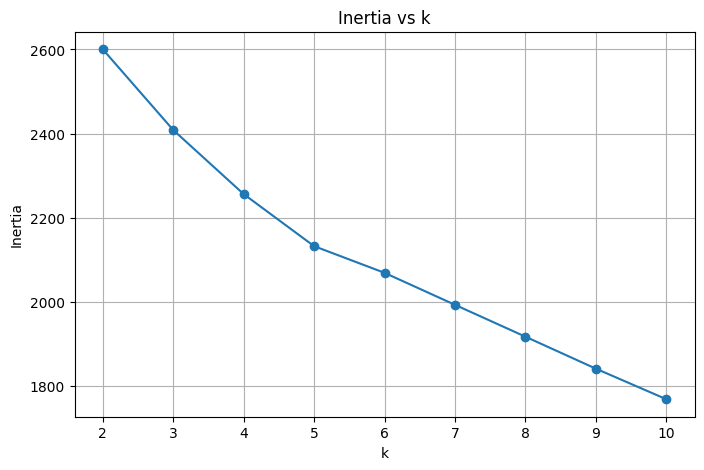

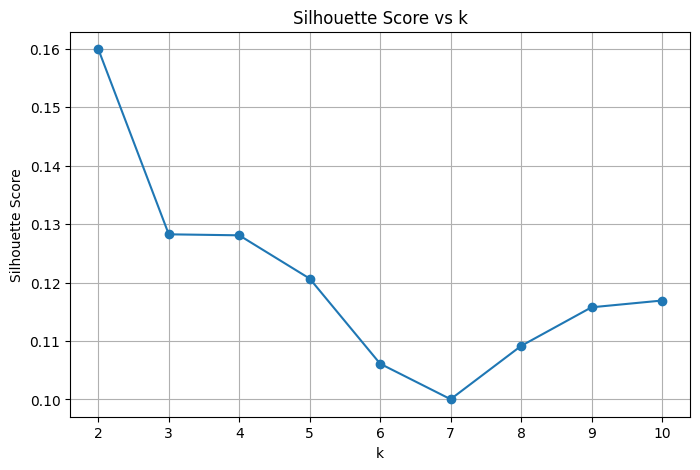

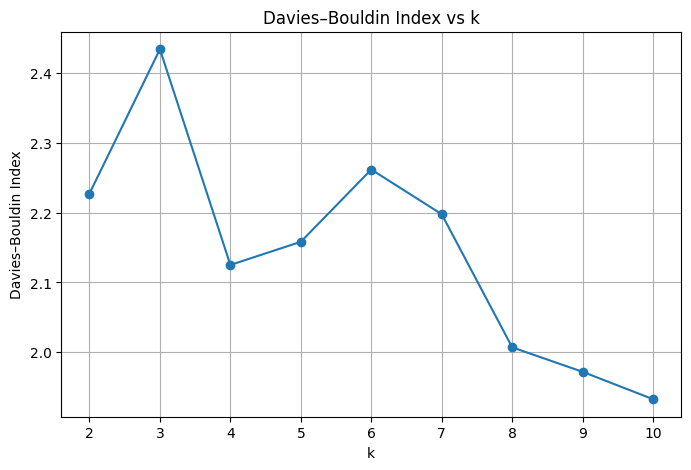

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(metrics_df["k"], metrics_df["Inertia"], marker="o")
plt.title("Inertia vs k")
plt.xlabel("k")
plt.ylabel("Inertia")
plt.grid(True)
plt.show()

plt.figure(figsize=(8,5))
plt.plot(metrics_df["k"], metrics_df["Silhouette"], marker="o")
plt.title("Silhouette Score vs k")
plt.xlabel("k")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.show()

plt.figure(figsize=(8,5))
plt.plot(metrics_df["k"], metrics_df["Davies-Bouldin"], marker="o")
plt.title("Davies–Bouldin Index vs k")
plt.xlabel("k")
plt.ylabel("Davies–Bouldin Index")
plt.grid(True)
plt.show()


#### 3.3 Interpretation of the metrics

- **Inertia** measures how close points are to their assigned cluster center (lower is better).  
  However, inertia **always decreases** when k increases, so it cannot alone determine the best k.

- **Silhouette Score** measures how well-separated clusters are (ranges roughly from -1 to 1).  
  **Higher is better**: values near 1 mean clusters are well separated, near 0 means overlapping clusters.

- **Davies–Bouldin Index** measures average similarity between each cluster and its most similar cluster.  
  **Lower is better**: small values indicate compact clusters that are far apart.

Overall, a good choice of k often has:
- relatively low inertia (but not necessarily minimal),
- a **high silhouette score**,
- a **low Davies–Bouldin index**.


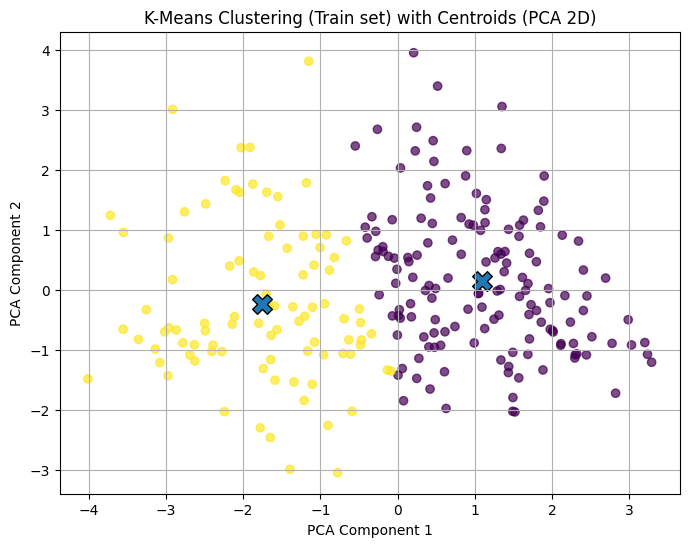

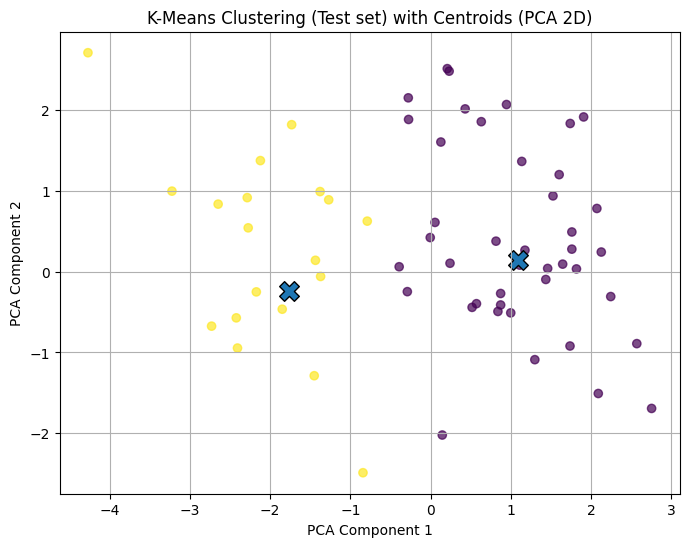

In [27]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# Fit PCA on training set (2 components for visualization)
pca = PCA(n_components=2, random_state=42)
x_train_2d = pca.fit_transform(x_train)
x_test_2d = pca.transform(x_test)

# Transform centroids too
centroids_2d = pca.transform(kmeans.cluster_centers_)

# Plot training data clustering
plt.figure(figsize=(8,6))
plt.scatter(x_train_2d[:, 0], x_train_2d[:, 1], c=train_labels, alpha=0.7)
plt.scatter(centroids_2d[:, 0], centroids_2d[:, 1], marker="X", s=200, edgecolors="black")
plt.title("K-Means Clustering (Train set) with Centroids (PCA 2D)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.grid(True)
plt.show()

# Plot test data clustering
plt.figure(figsize=(8,6))
plt.scatter(x_test_2d[:, 0], x_test_2d[:, 1], c=test_labels, alpha=0.7)
plt.scatter(centroids_2d[:, 0], centroids_2d[:, 1], marker="X", s=200, edgecolors="black")
plt.title("K-Means Clustering (Test set) with Centroids (PCA 2D)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.grid(True)
plt.show()
